In [1]:
# from ultralytics import RTDETR

# model = RTDETR("rtdetr-l.pt")
# model.info()

# results = model.train(data='./Scananagrams.yolov8', epochs = 50, imgsz=640)

## Read in Image, Identify Tiles


image 1/1 c:\IzzysWorkshop\PeelBack\boardImages\16TilesWideView.jpg: 640x640 32 Tiles, 440.9ms
Speed: 3.0ms preprocess, 440.9ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 640)
average Tile Length: 164.84375
Total tiles scanned: 32


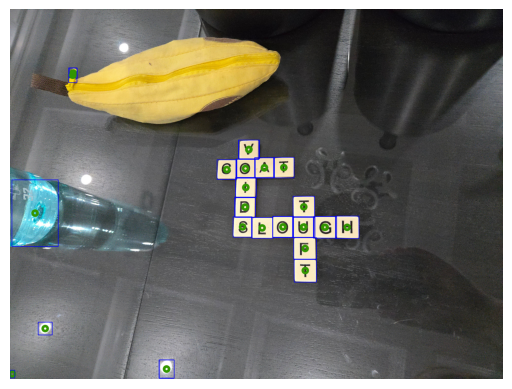

In [ ]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import RTDETR
import numpy as np
from Scananagrams.src import helper


imagePath = 'unAnnotatedImages/Reddit2.jpeg'

image = cv2.imread(imagePath, cv2.IMREAD_COLOR_RGB)

drawOn = image.copy()

myModel = RTDETR('runs/detect/train/weights/best.pt')
result = myModel.predict(imagePath)

boxes = result[0].boxes.xyxy.cpu().numpy()
boxes = boxes.astype(np.int64)
centers = []

for x1,y1,x2,y2 in boxes:
    # x1,y1,x2,y2 = map(int,box)
    xAvg = (x1+x2)//2
    yAvg = (y1+y2)//2
    centers.append([xAvg,yAvg])

    cv2.circle(drawOn, (xAvg,yAvg),20,(50,150,0),20)
    cv2.rectangle(drawOn, (x1,y1),(x2,y2), (0,0,250),3)

centers = np.asarray(centers)

avgTileLen = helper.findNewAvgTileLen(boxes)

print(f'average Tile Length: {avgTileLen}')
print(f'Total tiles scanned: {len(boxes)}')
plt.imshow(drawOn)
plt.axis('off')
plt.show()

## Filter for duplicates and false positives

### Filter By Aspect Ratio 

In [3]:
heights = boxes[:,3] - boxes[:,1]
widths = boxes[:,2] - boxes[:,0]
aspectRatios = widths/heights

ratioMOE = .1
minRatio, maxRatio = helper.percentCI(1,ratioMOE)

conditions = (.9<aspectRatios) & (aspectRatios<1.1) 
boxes = boxes[conditions]
centers=centers[conditions]
len(boxes)

25

### Filter by Length and Width

In [4]:
#avgTileLen needs to be recalculated now that ratio has been filtered
avgTileLen = helper.findNewAvgTileLen(boxes)

heights = boxes[:,3] - boxes[:,1]
widths = boxes[:,2] - boxes[:,0]

lenMOE = .25
minLen,maxLen = helper.percentCI(avgTileLen,lenMOE)

conditions = (widths<maxLen) & (widths>minLen) & (heights>minLen) & (heights<maxLen) 
boxes = boxes[conditions]
centers=centers[conditions]
len(boxes)


24

### Filter For Duplicates

In [5]:
from sklearn.neighbors import NearestNeighbors
neigh = NearestNeighbors(n_neighbors=6, algorithm='ball_tree').fit(centers)
indices = neigh.kneighbors(centers, return_distance=False)

In [6]:
avgTileLen = helper.findNewAvgTileLen(boxes)

duplicates=[]
for neighbors in indices:
    mainTile = centers[neighbors[0]]
    for neighbor in neighbors[1:]:
        diffX = mainTile[0] - centers[neighbor][0]
        diffY = mainTile[1] - centers[neighbor][1]
        if ( abs(diffX) < avgTileLen/2 and abs(diffY) < avgTileLen/2 ):
            print(f'Overlap found - ({mainTile[0]},{mainTile[1]}) and ({centers[neighbor][0]},{centers[neighbor][1]}) ')
            if(neighbors[0] not in duplicates):
                duplicates.append(neighbor)

boxes=np.delete(boxes,duplicates,axis=0)
centers = np.delete(centers,duplicates, axis=0)

len(centers)

Overlap found - (2553,1768) and (2558,1768) 
Overlap found - (1758,1299) and (1760,1299) 
Overlap found - (2214,1766) and (2216,1764) 
Overlap found - (1909,1605) and (1907,1604) 
Overlap found - (2064,1286) and (2065,1284) 
Overlap found - (1913,1445) and (1914,1444) 
Overlap found - (2380,1767) and (2385,1765) 
Overlap found - (1907,1604) and (1909,1605) 
Overlap found - (1760,1299) and (1758,1299) 
Overlap found - (1914,1444) and (1913,1445) 
Overlap found - (2216,1764) and (2214,1766) 
Overlap found - (2065,1284) and (2064,1286) 
Overlap found - (2558,1768) and (2553,1768) 
Overlap found - (2395,1940) and (2395,1940) 
Overlap found - (2395,1940) and (2395,1940) 
Overlap found - (2385,1765) and (2380,1767) 


16

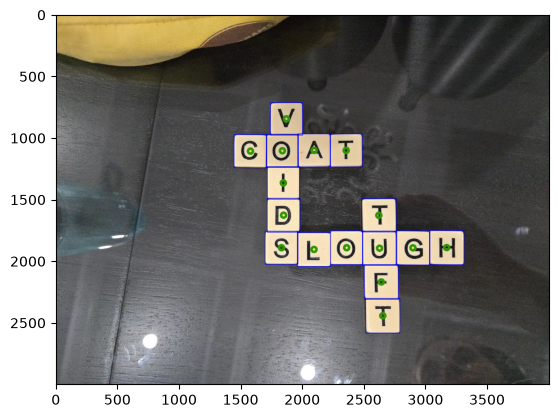

16

In [54]:
drawOn2 = image.copy()

for x1,y1,x2,y2 in boxes:
    xAvg = (x1+x2)//2
    yAvg = (y1+y2)//2
    avgTileLen += x2-x1
    avgTileLen += y2-y1

    cv2.circle(drawOn2, (xAvg,yAvg),20,(50,150,0),20)
    cv2.rectangle(drawOn2, (x1,y1),(x2,y2), (0,0,250),3)

plt.imshow(drawOn2)
plt.show()
len(boxes)

## Crop and export

In [ ]:
from cv2.typing import MatLike

def getCropped(image:MatLike, box) -> MatLike:
    x1,y1,x2,y2 = map(int, box)
    croppedImage = image[y1:y2,x1:x2]
    return croppedImage

def exportImage(image:MatLike, fileName, basePath='cnnTraining'):
    fullPath = f'./{basePath}/{fileName}.jpg'
    cv2.imwrite(fullPath,image)

In [ ]:
# import os

# batch = 'Batch2'
# imageDir = 'cnnTraining/_Full_Images'
# fullPath = os.path.join(imageDir,batch)
# print(fullPath)
# count = 0

# images = [imageFile for _,_, imageFile in os.walk(fullPath)][0]
# print(images)

# for imageFilePath in images:
#     imageFullPath = os.path.join(fullPath,imageFilePath)
#     image = cv2.imread(imageFullPath)
#     result = myModel.predict(image)
#     boxes = result[0].boxes.xyxy.cpu().numpy()
#     for crop in boxes:
#         croppedImage = getCropped(image,crop)
#         croppedOutPath = os.path.join('cnnTraining',f'{count}.jpg')
#         exportImage(croppedImage,str(count))
#         count+=1


cnnTraining/_Full_Images\Batch1
['20260819_211004.jpg', '20260819_211006.jpg', '20260819_211031.jpg', '20260819_211035.jpg', '20260819_211058.jpg', '20260819_211105.jpg', '20260819_211108.jpg', '20260819_211120.jpg', '20260819_211121.jpg', '20260819_211208.jpg', '20260819_211209.jpg', '20260819_211218.jpg', '20260819_211221.jpg', '20260819_211224.jpg']

0: 640x640 53 Tiles, 448.3ms
Speed: 6.3ms preprocess, 448.3ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 640)
cnnTraining\0.jpg
cnnTraining\1.jpg
cnnTraining\2.jpg
cnnTraining\3.jpg
cnnTraining\4.jpg
cnnTraining\5.jpg
cnnTraining\6.jpg
cnnTraining\7.jpg
cnnTraining\8.jpg
cnnTraining\9.jpg
cnnTraining\10.jpg
cnnTraining\11.jpg
cnnTraining\12.jpg
cnnTraining\13.jpg
cnnTraining\14.jpg
cnnTraining\15.jpg
cnnTraining\16.jpg
cnnTraining\17.jpg
cnnTraining\18.jpg
cnnTraining\19.jpg
cnnTraining\20.jpg
cnnTraining\21.jpg
cnnTraining\22.jpg
cnnTraining\23.jpg
cnnTraining\24.jpg
cnnTraining\25.jpg
cnnTraining\26.jpg
cnnTraining\27

## Determine Letter of Each Box

In [40]:
import torch
import string
from Scananagrams.src.cnn.OCRModel import SingleCharOCR, ImageDataset
from torch.utils.data import DataLoader
from torchvision.transforms import transforms


cv_letters = [ image[y1:y2,x1:x2] for x1,y1,x2,y2 in boxes]
transform = transforms.Compose([
    transforms.Resize((20,20)),
    transforms.ToTensor()
])
dataset = ImageDataset(cv_letters,transform)
dataloader = DataLoader(dataset, batch_size=1, shuffle=False)


model = SingleCharOCR()
model.load_state_dict(torch.load('cnnTraining/weights/firstAttempt.pt', weights_only=True))
model.eval()

outputs = []

with torch.inference_mode():
    for batch in  dataloader:
        outputs.append(model(batch)[0])

outputs = torch.stack(outputs)
outs=torch.argmax(outputs,1)
letters = np.asarray(list(string.ascii_uppercase))
tileLetters = letters[outs]
tileLetters

array(['H', 'T', 'T', 'G', 'C', 'S', 'V', 'O', 'T', 'D', 'A', 'O', 'L', 'U', 'L', 'F'], dtype='<U1')

## Give each box a letter, create `TileInfo` Objects

In [34]:
from Scananagrams.src.TileNeighbors import TileNeighbors
class TileInfo():
    def __init__(self, center, letter):
        self.center = center
        self.letter=letter
        self.tileDict = TileNeighbors()

    def setNeighbors(self, tileDict:TileNeighbors):
        self.tileDict=tileDict

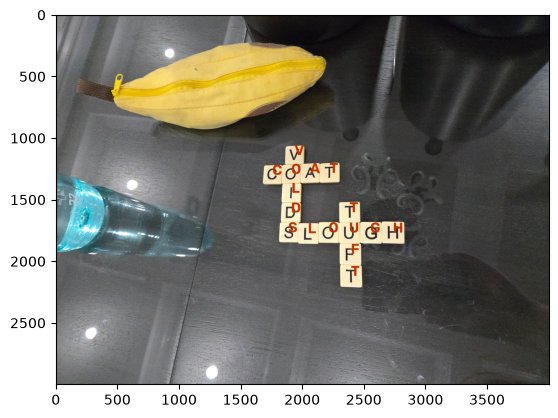

In [43]:
tiles = [TileInfo(center,letter) for center,letter in zip(centers,tileLetters)]
drawOnFinal = image.copy()

for tile in tiles:
    # print(tile.letter)
    cv2.putText(drawOnFinal, tile.letter, tile.center, cv2.FONT_HERSHEY_SIMPLEX, 4.0, (190,50,0),2,bottomLeftOrigin=False)
plt.imshow(drawOnFinal)
plt.show()

## Visualize board with BFS using only letters

## Letters --> Words

## Visualize board using words and intersect indices

## Neighbors 1